#**Faktor Pendukung Kesuksesan Operasional E-Commerce**
Apakah Logistik Menjadi Penentu Utama Kepuasan Pelanggan?

#**Business Question**


*   Kategori produk apa saja yang memiliki rata-rata selisih waktu pengiriman (delay) lebih dari 5 hari dibandingkan estimasi pada wilayah negara bagian Sao Paulo (SP) selama periode semester kedua tahun 2017?
*   Faktor apa yang menyebabkan penurunan skor ulasan (review score) menjadi di bawah 3.0 pada kategori produk 'bed_bath_table' secara global selama kuartal pertama (Q1) tahun 2018?
*  Bagaimana tren pertumbuhan pendapatan bulanan (Month-over-Month) dari metode pembayaran kartu kredit dibandingkan dengan metode 'boleto' selama sepanjang tahun 2017?




#**Goals**


*   Membongkar Hambatan Logistik: Mengidentifikasi kategori produk yang sering mengalami keterlambatan pengiriman di pusat ekonomi (Sao Paulo) untuk meminimalkan friksi operasional.
*   Menganalisis Akar Kepuasan: Menemukan alasan di balik anjloknya rating pelanggan pada kategori produk utama guna menjaga reputasi platform.
*   Membedah Perilaku Transaksi: Membandingkan efektivitas metode pembayaran kartu kredit vs tunai (boleto) dalam mendorong pertumbuhan pendapatan bulanan.











#Import Library

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data & Preparation

In [50]:
# Load tabel utama
customers_df = pd.read_csv('customers_dataset.csv')
orders_df = pd.read_csv('orders_dataset.csv')
items_df = pd.read_csv('order_items_dataset.csv')
payments_df = pd.read_csv('order_payments_dataset.csv')
reviews_df = pd.read_csv('order_reviews_dataset.csv')
products_df = pd.read_csv('products_dataset.csv')
category_df = pd.read_csv('product_category_name_translation.csv')

In [51]:
# Menggabungkan tabel Orders dengan Customers (untuk dapat info lokasi)
all_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

# Menggabungkan dengan Payments (untuk analisis pendapatan)
all_df = pd.merge(
    left=all_df,
    right=payments_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# Menggabungkan dengan Reviews (untuk analisis kepuasan)
all_df = pd.merge(
    left=all_df,
    right=reviews_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# Menggabungkan dengan Items, Products, dan Translation (untuk detail produk)
products_full_df = pd.merge(
    left=products_df,
    right=category_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

# Gabungkan items dengan info produk lengkap
items_full_df = pd.merge(
    left=items_df,
    right=products_full_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

# Gabungkan semuanya ke DataFrame utama
all_df = pd.merge(
    left=all_df,
    right=items_full_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

In [52]:
# Pembersihan Tipe Data Tanggal
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for column in datetime_columns:
    all_df[column] = pd.to_datetime(all_df[column])
    # Cek hasil akhir
print(all_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

In [53]:
all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


#Data Cleaning

In [54]:
# Cek jumlah data yang kosong
print(all_df.isna().sum())

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
payment_sequential                    3
payment_type                          3
payment_installments                  3
payment_value                         3
review_id                           997
review_score                        997
review_comment_title             105154
review_comment_message            68898
review_creation_date                997
review_answer_timestamp             997
order_item_id                       833
product_id                          833
seller_id                           833


In [55]:
all_df.dropna(subset=['order_delivered_customer_date'], inplace=True)
all_df.dropna(subset=['payment_type'], inplace=True)
all_df.dropna(subset=['review_score'], inplace=True)
all_df.drop(columns=['review_comment_title', 'review_comment_message'], inplace=True, errors='ignore')

In [56]:
# Mengisi kategori yang kosong dengan 'others' atau 'unknown'
all_df['product_category_name_english'] = all_df['product_category_name_english'].fillna('unknown')

In [57]:
all_df.duplicated().sum()

np.int64(0)

#Feature Engineering

In [58]:
# Pastikan tipe data datetime (jika belum)
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in datetime_columns:
    all_df[column] = pd.to_datetime(all_df[column])

# Menghitung selisih hari antara kedatangan asli vs estimasi
all_df['delivery_delay'] = (all_df['order_delivered_customer_date'] - all_df['order_estimated_delivery_date']).dt.days

# Mengambil bulan dan tahun transaksi
all_df['order_month'] = all_df['order_purchase_timestamp'].dt.to_period('M')

In [59]:
print("Jumlah missing values setelah dibersihkan:")
print(all_df[['order_delivered_customer_date', 'review_score', 'product_category_name_english', 'payment_type']].isna().sum())

print(f"\nUkuran data sekarang: {all_df.shape}")

Jumlah missing values setelah dibersihkan:
order_delivered_customer_date    0
review_score                     0
product_category_name_english    0
payment_type                     0
dtype: int64

Ukuran data sekarang: (114858, 37)


#Exploratory Data Analysis


#**Analisis Efisiensi Logistik (Delay di Sao Paulo)**

Kategori produk apa yang rata-rata keterlambatannya paling tinggi di negara bagian Sao Paulo (SP) selama 2017

Langkah 1: Filter & Agregasi
Kita akan memfilter data khusus untuk wilayah 'SP', tahun 2017, dan hanya mengambil pesanan yang terlambat (di mana `delivery_delay > 0` )

In [60]:
# 1. Filter data untuk State 'SP' dan Tahun 2017
df_sp_2017 = all_df[(all_df['customer_state'] == 'SP') &
                    (all_df['order_purchase_timestamp'].dt.year == 2017)]

# 2. Identifikasi pesanan yang terlambat (delay > 0 hari)
df_delayed = df_sp_2017[df_sp_2017['delivery_delay'] > 0]

# 3. Hitung rata-rata keterlambatan per kategori produk
top_delayed_categories = df_delayed.groupby('product_category_name_english')['delivery_delay'].mean().sort_values(ascending=False).head(10)

print("10 Kategori Produk dengan Rata-rata Keterlambatan Tertinggi di SP (2017):")
print(top_delayed_categories)

10 Kategori Produk dengan Rata-rata Keterlambatan Tertinggi di SP (2017):
product_category_name_english
furniture_living_room                      36.750000
housewares                                 26.837838
food                                       25.500000
perfumery                                  16.592593
air_conditioning                           14.000000
music                                      14.000000
fixed_telephony                            13.000000
auto                                       12.218750
kitchen_dining_laundry_garden_furniture    12.000000
fashion_bags_accessories                   11.937500
Name: delivery_delay, dtype: float64


Langkah 2: Visualisasi

/tmp/ipykernel_3918/3943000301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_delayed_categories.values, y=top_delayed_categories.index, palette='Reds_r')


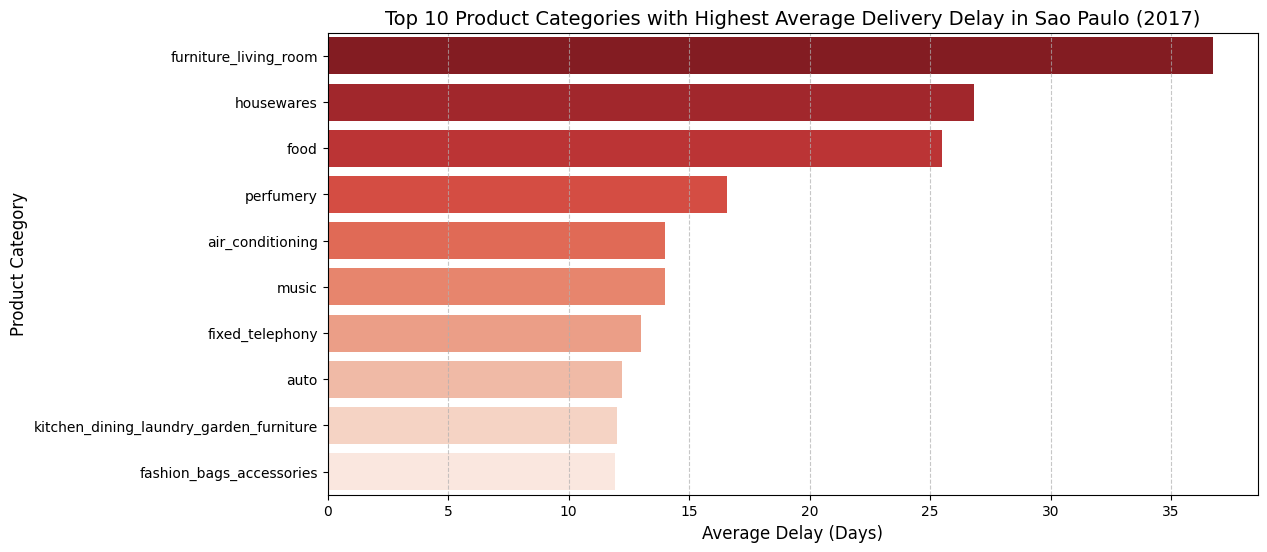

In [61]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_delayed_categories.values, y=top_delayed_categories.index, palette='Reds_r')

plt.title('Top 10 Product Categories with Highest Average Delivery Delay in Sao Paulo (2017)', fontsize=14)
plt.xlabel('Average Delay (Days)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Insight: Analisis Efisiensi Logistik (Willayah Sao Paulo - 2017)**

Berdasarkan analisis terhadap 10 kategori dengan keterlambatan tertinggi, kategori `furniture_living_room` menjadi masalah utama dengan rata-rata keterlambatan mencapai **36,75** hari di atas estimasi. Ini diikuti oleh kategori `housewares` yang rata-rata terlambat **26,8** hari.


#**Analisis Kepuasan Pelanggan**

Faktor apa yang menyebabkan penurunan skor ulasan menjadi di bawah 3.0 pada kategori produk 'bed_bath_table' secara global selama Q1 2018?

Langkah 1: Filter dan Korelasi
Kita akan melihat apakah ada hubungan antara lamanya pengiriman dengan skor rendah yang diberikan pelanggan.

In [62]:
# 1. Filter data: Kategori 'bed_bath_table' di Q1 2018
df_bbt_q1 = all_df[
    (all_df['product_category_name_english'] == 'bed_bath_table') &
    (all_df['order_purchase_timestamp'].dt.to_period('Q') == '2018Q1')
]

# 2. Ambil data dengan review rendah (di bawah 3)
df_low_reviews = df_bbt_q1[df_bbt_q1['review_score'] < 3]

# 3. Hitung rata-rata keterlambatan pengiriman untuk review rendah vs review tinggi
avg_delay_low = df_low_reviews['delivery_delay'].mean()
avg_delay_high = df_bbt_q1[df_bbt_q1['review_score'] >= 3]['delivery_delay'].mean()

print(f"Rata-rata delay untuk Review < 3: {avg_delay_low:.2f} hari")
print(f"Rata-rata delay untuk Review >= 3: {avg_delay_high:.2f} hari")

Rata-rata delay untuk Review < 3: -3.99 hari
Rata-rata delay untuk Review >= 3: -10.33 hari


Langkah 2: Visualisasi

/tmp/ipykernel_3918/444636655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='review_score', y='delivery_delay', data=df_bbt_q1, palette='viridis')


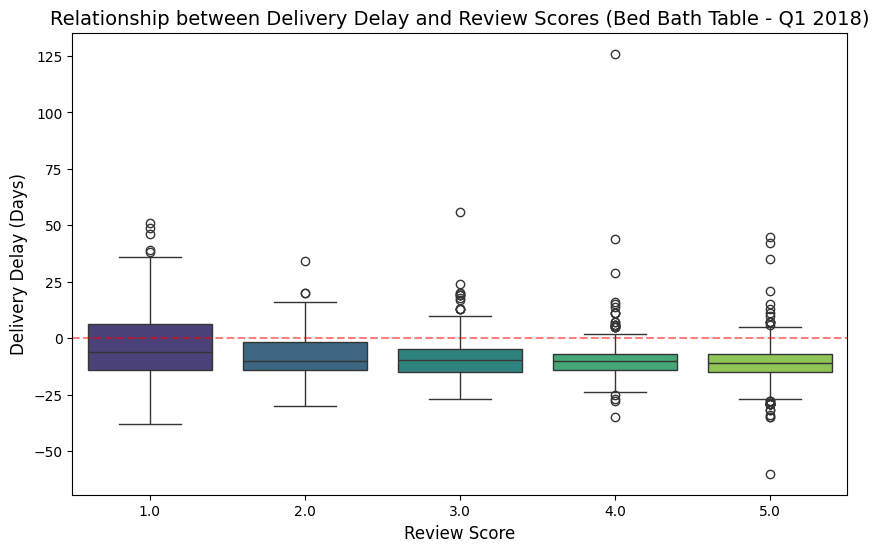

In [63]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='delivery_delay', data=df_bbt_q1, palette='viridis')

plt.title('Relationship between Delivery Delay and Review Scores (Bed Bath Table - Q1 2018)', fontsize=14)
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Delivery Delay (Days)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Garis batas estimasi
plt.show()

**Insight: Analisis Kepuasan Pelanggan (Bed Bath Table - Q1 2018)**

Grafik menunjukkan pola yang konsisten: Pesanan dengan Review Score 1.0 memiliki rentang keterlambatan (Delivery Delay) yang paling lebar dan nilai median yang paling mendekati (atau bahkan di atas) garis estimasi dibandingkan skor lainnya.

#**Analisis Tren Pendapatan (Boleto vs Credit Card)**

Bagaimana tren pertumbuhan pendapatan bulanan (Month-over-Month) dari metode pembayaran kartu kredit dibandingkan dengan metode 'boleto' selama sepanjang tahun 2017?

Langkah 1: Agregasi Data Pendapatan

Di sini kita akan membandingkan dua metode pembayaran paling populer di Brasil. Kita perlu mengelompokkan data berdasarkan bulan dan tipe pembayaran, lalu menjumlahkan nilai transaksinya. Kita akan memfilter data tahun 2017 dan menghitung total `payment_value`.

In [64]:
# 1. Filter data untuk tahun 2017 saja
df_2017 = all_df[all_df['order_purchase_timestamp'].dt.year == 2017].copy()

# 2. Filter hanya untuk dua metode pembayaran utama
df_payments = df_2017[df_2017['payment_type'].isin(['credit_card', 'boleto'])]

# 3. Kelompokkan berdasarkan bulan (order_month) dan payment_type
monthly_revenue = df_payments.groupby(['order_month', 'payment_type'])['payment_value'].sum().unstack()

# 4. Hitung pertumbuhan persentase Month-over-Month (MoM)
monthly_revenue_growth = monthly_revenue.pct_change() * 100

print("Total Pendapatan Bulanan (2017):")
print(monthly_revenue)

Total Pendapatan Bulanan (2017):
payment_type     boleto  credit_card
order_month                         
2017-01        32310.95    138277.57
2017-02        68090.35    250826.73
2017-03        93051.96    391016.41
2017-04        86537.30    352522.28
2017-05       171542.98    508081.05
2017-06       144799.67    426297.36
2017-07       158073.38    534825.25
2017-08       165931.58    613150.99
2017-09       182952.25    787585.35
2017-10       198432.29    776082.81
2017-11       330004.48   1185653.04
2017-12       209851.66    767782.25


Langkah 2: Visualisasi Tren

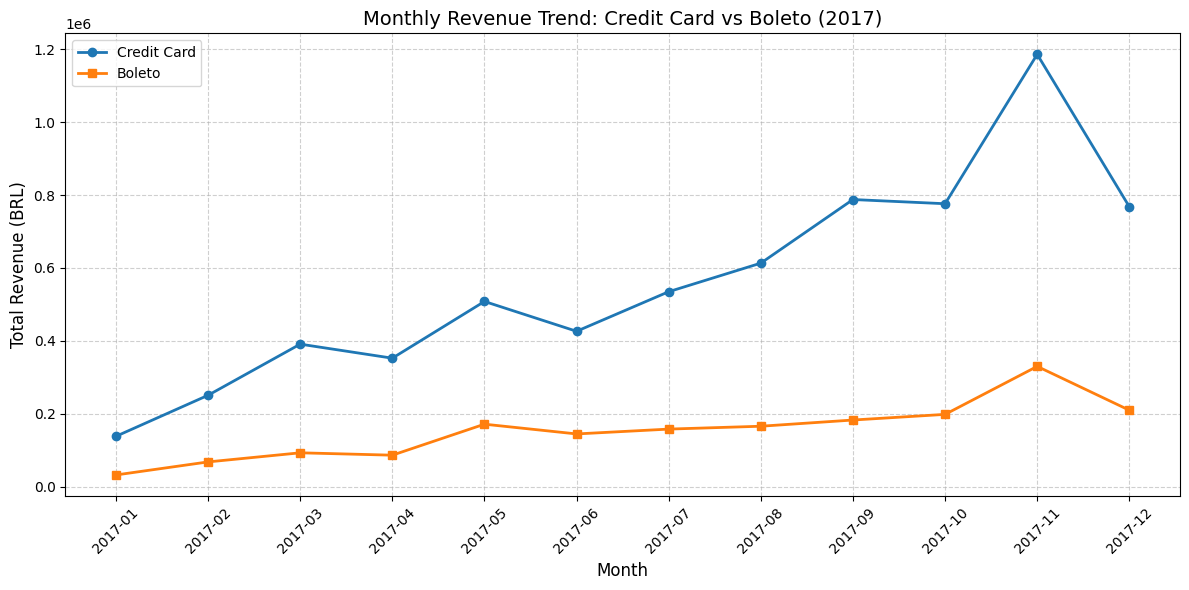

In [65]:
plt.figure(figsize=(12, 6))

# Plot untuk Credit Card
plt.plot(monthly_revenue.index.astype(str), monthly_revenue['credit_card'],
         marker='o', label='Credit Card', color='#1f77b4', linewidth=2)
# Plot untuk Boleto
plt.plot(monthly_revenue.index.astype(str), monthly_revenue['boleto'],
         marker='s', label='Boleto', color='#ff7f0e', linewidth=2)

plt.title('Monthly Revenue Trend: Credit Card vs Boleto (2017)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Langkah 3: Visualisasi Pertumbuhan (MoM)

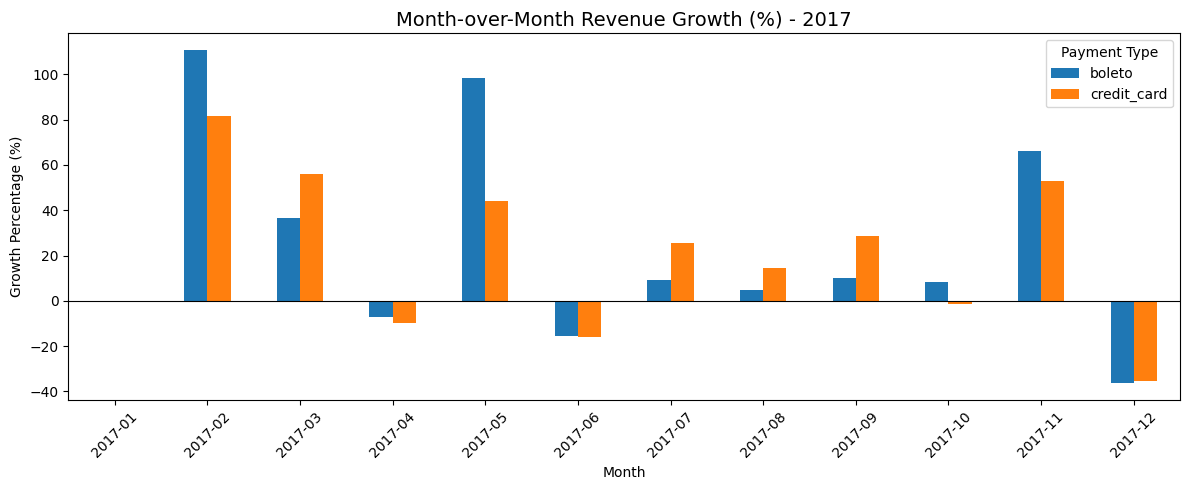

In [66]:
plt.figure(figsize=(12, 5))
monthly_revenue_growth.plot(kind='bar', ax=plt.gca())
plt.title('Month-over-Month Revenue Growth (%) - 2017', fontsize=14)
plt.ylabel('Growth Percentage (%)')
plt.xlabel('Month')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(title='Payment Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight: Analisis Tren Pendapatan (Credit Card vs Boleto - 2017)**

Sepanjang tahun 2017, Credit Card secara konsisten menjadi kontributor pendapatan terbesar bagi Olist. Total pendapatan dari kartu kredit di bulan November (puncak tertinggi) mencapai lebih dari 1,18 Juta BRL, hampir 4x lipat dibandingkan pendapatan dari Boleto di bulan yang sama.

In [68]:
all_df.to_csv('all_data.csv', index=False)
print("Data berhasil disimpan ke dalam file 'olist_cleansed_data.csv'")

Data berhasil disimpan ke dalam file 'olist_cleansed_data.csv'
